### **Projeto extensionista  do curso Tópicos de Big Data em Python**
- Faculdate Estacio de Sá RJ (Unesa)
- Aluno: José Roberto Duarte Hegendorne
- Matrícula: 202502214154
- Curso Presencial
- Professora: Simone Gama
- Período: 1ª semestre 2026
---

### **Dados do Sistema de Bilhetagem Eletrônica**

**URL dos dados analizados:** 
https://dadosabertos.rj.gov.br/dataset/setram_sbe

---


## **Repositório de dados baixados**
- https://dadosabertos.rj.gov.br/dataset/setram_sbe
**link do repósitorio do drive é** 
- https://drive.google.com/drive/folders/1486i6aBSUVuyrD6bISm0qYGZs-eIhK71?usp=sharing

*os arquivos são distribuidos com a movimentação diaria do bilhete unico, fazer o carregamento disso, em grandes periodos , requer um hardware com mais recursos*

---



## **Dicionario de Dados dos arquivos originais presentes na página de dados oficiais do governo:** 
#### Cartão Hash:** 
  - Sequência única de caracteres gerada a partir do Nº Cartão.
  
#### Data da Transação:
#### Data e hora do processamento da transação
#### Data do Processamento
#### Descrição da Aplicação

   **Código da aplicação do cartão**
   - 100 - Expresso
   - 400 - Vale-transporte, 
   - 450 - Empresarial, 
   - 820 - Gratuidade de Morador de Paquetá/Ilha Grande, 
   - 80 QRCode Unitário
    
#### Linha
  - Número e nome da Linha.
#### Nº Carro
  - Número da estação ou do carro onde a transação foi realizada.
#### Nº Cartão
  - Número externo do cartão do usuário. Informação anonimizada para atender a LGPD, conforme exemplo a seguir: 1091xxxxxx713.
#### Nº Validador
  - Número do validador utilizado na transação.
#### Operadora
  -  Nome da Operadora de transporte. 
      _Informação anonimizada para as Vans para atender a LGPD, conforme exemplo a seguir: VAN560001-LUISA MAxxxxxxxx_
#### Sentido
  - Código do sentido da linha (0 - não informado, 1 - ida, 2 - volta).
#### Sindicato
  - Nome do sindicato
#### Vl Linha
  - Valor da linha da operadora de transporte.
#### Vl Subsídio
  - Valor do subsídio.
#### Vl Trans
  - Valor descontado no cartão do usuário.



## Classificação das Variáveis

### Variáveis Numéricas

- Vl_Linha
- Vl_Trans
- Vl_Subsidio

### Variáveis Categóricas

- Descricao_da_Aplicacao
- Operadora
- Linha
- Sindicato
- Sentido

### Variáveis Temporais

- Data_da_Transacao
- Data_do_Processamento  
 

**Variaveis declaradas:**
  - Pd - pandas 
  - Bu_total - data frame que recebe o CSV sem tratamento
  - Bu - data frame com Csv tratado
  - colunas - lista os campos que irei utilizar 

 **Bibliotecas Python:** 
 - Pandas,
 - Numpy,
 - MatplotLib,
 - Sklearn,
 - seaborn.




Importando as bibliotecas

In [149]:
import pandas as Pd                                         # Biblioteca para manipulação de dados              
import numpy as np                                          # Biblioteca para cálculos numéricos
import matplotlib.pyplot as plt                             # Biblioteca para gráficos
import seaborn as sns                                        # Biblioteca para gráficos estatísticos
sns.set(style="whitegrid")
from sklearn.linear_model import LinearRegression            # Biblioteca para regressão linear
from sklearn.metrics import mean_squared_error, r2_score     # Biblioteca para métricas de regressão


Fazendo Carregamento da Base CSV do Bilhete unico

In [150]:
# Utilizando a função para carregar os dados com um número específico de linhas para facilitar o desenvolvimento e testes iniciais
#Diretorio = "D:\\python\\facul\\"
Diretorio = "https://raw.githubusercontent.com/Heggendorn/facul/28891d6650bda3a6f37adf0ae0968681f228fd3c/"
nome_arquivo = "TRANSACAO_BE_PUBLICO_2026_03_22"
def Carregar_Dados(quantidade_linhas=None, arquivo=r""):
  try:
    dados_df =  Pd.read_csv(arquivo, encoding='utf-8-sig', sep=';', nrows=quantidade_linhas)
    return dados_df
  except Exception:
    print(f"Erro ao carregar os dados")
    return None
  
Bu_total = Carregar_Dados(None, Diretorio + nome_arquivo + ".csv") 


Estou estruturando os campos do arquivo CSV à serem tratados,
Removi rash e o numero do cartão do passageiro porque eles esconderam o numero real com caracteres X Nº  2024XXXXX3128     

In [151]:
# Listando os campos que serão utilizados para a análise, garantindo que o dataframe Bu seja uma cópia do dataframe Bu_total, evitando alterações indesejadas no dataframe original.
colunas = [
    "Data da Transação",
    "Descrição da Aplicação",
    "Sentido",
    "Nº Validador",
    "Sindicato",
    "Operadora",
    "Linha",
    "Nº Carro",
    "Vl Linha",
    "Vl Trans",
    "Vl Subsídio"
]
Bu = Bu_total[colunas].copy()
#garantindo que o dataframe Bu seja uma cópia do dataframe Bu_total, evitando alterações indesejadas no dataframe original.  

### TRATAMENTO DOS DADOS 
##### ----------------------------------------------------------


###  Renomeando as colunas das tabelas, Removendo espaços , caracteres especiais  utilizando .rename (columns={"xx":"yy"}) 

In [152]:
Bu.rename(columns={"Data do Processamento": "Data_do_Processamento",    
    "Data da Transação":"Data_da_Transacao",
    "Descrição da Aplicação":"Descricao_da_Aplicacao",
    "Nº Validador":"N_Validador",
    "Nº Carro": "N_Carro",
    "Vl Linha":"Vl_Linha",
    "Vl Trans":"Vl_Trans",
    "Vl Subsídio":"Vl_Subsidio"}, inplace=True)    # inplace=True é necessario para manter salvo as mudanças no dataframe Bu, sem a necessidade de criar um novo dataframe para armazenar as mudanças.

#------------------------------------------------------
#exibindo as inforamações da tabela para verificar a alteração dos nomes das colunas e o tipo de dados de cada coluna, além de verificar se há valores nulos ou não.
Bu.info()

<class 'pandas.DataFrame'>
RangeIndex: 409254 entries, 0 to 409253
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Data_da_Transacao       409254 non-null  str    
 1   Descricao_da_Aplicacao  409254 non-null  str    
 2   Sentido                 402146 non-null  float64
 3   N_Validador             409254 non-null  int64  
 4   Sindicato               409254 non-null  str    
 5   Operadora               409254 non-null  str    
 6   Linha                   409254 non-null  str    
 7   N_Carro                 409254 non-null  int64  
 8   Vl_Linha                409254 non-null  str    
 9   Vl_Trans                409254 non-null  str    
 10  Vl_Subsidio             199141 non-null  str    
dtypes: float64(1), int64(2), str(8)
memory usage: 34.3 MB


### Tratando o Campo "Sentido"

### Sentido:
  -      Código do sentido da linha (0 - não informado, 1 - ida, 2 - volta).
  -      Tudo que estiver vazio(NaN) receberá 0
  -      Convertendo o campo em Inteiro pois esta como float .astype(int)
  -      Precisei arredondar para converter usando .round()


In [153]:
Bu["Sentido"] = Bu["Sentido"].fillna(0) # a função filna do panda preenche o vazio com 0 (zero)
Bu["Sentido"] = Bu["Sentido"].round().astype(int) # arredondando com round e convertendo para inteiro
Bu["Sentido"] = Bu["Sentido"].map({0: "Desconecido", 1: "Ida", 2: "Volta"}) # mapeando os valores para as 

### Tratando valor do subsidio   "Vl Subsídio"  porque há valores vazios (NaN), fiz remocao de strings, ponto pra caracterizar milhar e substituir , por . para converter em float


In [154]:
Bu["Vl_Subsidio"] = Bu["Vl_Subsidio"].fillna(0)  # 
Bu['Vl_Subsidio'] = (
    Bu['Vl_Subsidio']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace('.', '', regex=False)   # remove separador de milhar
    .str.replace(',', '.', regex=False)  # converte decimal brasileiro
    .str.strip().astype(float)
)

## Tratando os campos que contém data. pois o formato esta em string
mudou o padrão de XX / XX / XXXX para xx-xx-xxxx  

In [155]:
# tratando campo de data colocando os dias como primeiro(dayfirst)
Bu["Data_da_Transacao"] = Pd.to_datetime(Bu["Data_da_Transacao"],dayfirst=True,errors='coerce') #coerce joga valores invalidos para NaT (Not a Time)
# a função to_datetime do pandas converte a coluna de data para o formato datetime, com dayfirst=True para garantir que o dia seja interpretado como o primeiro elemento da data, e errors='coerce' para lidar com valores inválidos, convertendo-os para NaT (Not a Time).


# trocando valores  de ","   para "." e convertendo para float
Bu["Vl_Linha"] = Bu["Vl_Linha"].str.replace(",", ".").astype(float)
Bu["Vl_Trans"] = Bu["Vl_Trans"].str.replace(",", ".").astype(float)

Bu.info()

<class 'pandas.DataFrame'>
RangeIndex: 409254 entries, 0 to 409253
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Data_da_Transacao       409254 non-null  datetime64[us]
 1   Descricao_da_Aplicacao  409254 non-null  str           
 2   Sentido                 409254 non-null  str           
 3   N_Validador             409254 non-null  int64         
 4   Sindicato               409254 non-null  str           
 5   Operadora               409254 non-null  str           
 6   Linha                   409254 non-null  str           
 7   N_Carro                 409254 non-null  int64         
 8   Vl_Linha                409254 non-null  float64       
 9   Vl_Trans                409254 non-null  float64       
 10  Vl_Subsidio             409254 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(5)
memory usage: 34.3 MB


Limpando os campos vazio dos campos dos campos que são string

Descricao_da_Aplicacao , Operadora , Linha, Sindicato

In [156]:
Bu["Descricao_da_Aplicacao"] = Bu["Descricao_da_Aplicacao"].str.strip()
Bu["Operadora"] = Bu["Operadora"].str.strip()
Bu["Linha"] = Bu["Linha"].str.strip()
Bu["Sindicato"] = Bu["Sindicato"].str.strip()

In [157]:
# Exibe informações gerais da base
print('\n===== INFORMAÇÕES DA BASE =====')
print(Bu.info())


===== INFORMAÇÕES DA BASE =====
<class 'pandas.DataFrame'>
RangeIndex: 409254 entries, 0 to 409253
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Data_da_Transacao       409254 non-null  datetime64[us]
 1   Descricao_da_Aplicacao  409254 non-null  str           
 2   Sentido                 409254 non-null  str           
 3   N_Validador             409254 non-null  int64         
 4   Sindicato               409254 non-null  str           
 5   Operadora               409254 non-null  str           
 6   Linha                   409254 non-null  str           
 7   N_Carro                 409254 non-null  int64         
 8   Vl_Linha                409254 non-null  float64       
 9   Vl_Trans                409254 non-null  float64       
 10  Vl_Subsidio             409254 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(5)
memory usage: 34.3

In [158]:
# VERIFICAÇÃO DE DADOS AINDA NÃO TRATADOS
# ============================================================
# Verifica valores nulos
print('\n===== VALORES NULOS =====')
Bu.isnull().sum()


===== VALORES NULOS =====


Data_da_Transacao         0
Descricao_da_Aplicacao    0
Sentido                   0
N_Validador               0
Sindicato                 0
Operadora                 0
Linha                     0
N_Carro                   0
Vl_Linha                  0
Vl_Trans                  0
Vl_Subsidio               0
dtype: int64

In [159]:
# Verifica registros duplicados
print('\n===== REGISTROS DUPLICADOS =====')
print(Bu.duplicated().sum())


===== REGISTROS DUPLICADOS =====
72368


In [160]:
# Verifica tipos de dados
print('\n===== TIPOS DAS COLUNAS =====')
print(Bu.dtypes)
print('\n===== INFORMAÇÕES DA BASE =====')
print(Bu.info())


===== TIPOS DAS COLUNAS =====
Data_da_Transacao         datetime64[us]
Descricao_da_Aplicacao               str
Sentido                              str
N_Validador                        int64
Sindicato                            str
Operadora                            str
Linha                                str
N_Carro                            int64
Vl_Linha                         float64
Vl_Trans                         float64
Vl_Subsidio                      float64
dtype: object

===== INFORMAÇÕES DA BASE =====
<class 'pandas.DataFrame'>
RangeIndex: 409254 entries, 0 to 409253
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Data_da_Transacao       409254 non-null  datetime64[us]
 1   Descricao_da_Aplicacao  409254 non-null  str           
 2   Sentido                 409254 non-null  str           
 3   N_Validador             409254 non-null  int64         
 4   

Gerando os arquivos de backup sem dados removidos

In [161]:
#Bu_backup = Bu.copy()  # backup para comparação
#Bu_backup.to_csv(Diretorio +"bu_backup.csv", sep=';', index=False, encoding='utf-8-sig')  

Removendo dados irrelevantes para analise pois são passageiros com valor quantitativo 0.

In [162]:
Bu = Bu[
    Bu["Descricao_da_Aplicacao"] != "820-BARCAS MORADOR"
]

Resultado da Remoção

In [163]:
print("Total atual de registros: ", Bu.shape[0], "\nTotal de registros com valor de linha menor que R$:1,0: ", (Bu['Vl_Linha'] < 1).sum(), "\nPercentual de registros com valor de linha menor que 1: ", (Bu['Vl_Linha'] < 1).mean() * 100, "%")

print("Quantidade de registros com valor de linha menor que 1: ", (Bu['Vl_Linha'] < 1).sum())

print("Removi os registros com valor de linha menor que R$:1,0, totalizando: ", (Bu['Vl_Linha'] < 1).sum(), " registros removidos.")

Total atual de registros:  409054 
Total de registros com valor de linha menor que R$:1,0:  12 
Percentual de registros com valor de linha menor que 1:  0.002933598009064818 %
Quantidade de registros com valor de linha menor que 1:  12
Removi os registros com valor de linha menor que R$:1,0, totalizando:  12  registros removidos.


Salvando Banco de Dados tratado.

In [164]:
#Bu.to_csv( Diretorio + "dados_tratados_Bu.csv", sep=';', index=False, encoding='utf-8-sig')# encoding='utf-8-sig' garante a compatibilidade com caracteres acentuados, evitando problemas de codificação ao abrir o arquivo em diferentes sistemas operacionais ou softwares.

print("Total atual de registros: ", Bu.shape[0])

Total atual de registros:  409054


**Criando os Grupos em Elegiveis e não elegives"

## Fim do tratamento.
         ------------------------------------

In [165]:
print("Dimensão dos dados do bilhete unico:")
shape_linha, shape_coluna = Bu.shape # total de registros e total de colunas do dataframe Bu
print(f"No momento temos {shape_linha} Linhas,  e  {shape_coluna} Colunas")


Dimensão dos dados do bilhete unico:
No momento temos 409054 Linhas,  e  11 Colunas


In [166]:
# ==============================================================================
# # 1) ANÁLISE DESCRITIVA DA BASE DE DADOS
# ==============================================================================

# --- PASSO 1: Definição Estrita dos Grupos de Análise ---
G_Nao_elegiveis = [
    "80-QR CODE UNITÁRIO",
    "450-CARTÃO EMPRESARIAL"
]

G_Elegiveis = [
    "100-EXPRESSO",
    "400-VALE TRANSPORTE CONVENCIONAL"
]

# --- PASSO 2: Separação e Isolamento dos DataFrames ---
Bu_nao_elegiveis = Bu[Bu["Descricao_da_Aplicacao"].isin(G_Nao_elegiveis)].copy()
Bu_elegiveis = Bu[Bu["Descricao_da_Aplicacao"].isin(G_Elegiveis)].copy()

# --- PASSO 3: Validação Estrutural Pós-Agrupamento (Substitui os .info() soltos) ---
print("===== VALIDAÇÃO VOLUMÉTRICA DOS GRUPOS =====")
print(f"Base Total: {Bu.shape[0]} linhas")
print(f"Grupo Não Elegíveis: {Bu_nao_elegiveis.shape[0]} linhas")
print(f"Grupo Elegíveis: {Bu_elegiveis.shape[0]} linhas")
print(f"Diferença residual (se houver): {Bu.shape[0] - (Bu_nao_elegiveis.shape[0] + Bu_nao_elegiveis.shape[0])}")

# --- PASSO 4: Execução da Análise Descritiva Automatizada ---
def analise_descritiva(dframe, nome):
    print(f"\n{'='*45}")
    print(f"{' '*7}ANÁLISE DESCRITIVA - {nome}")
    print(f"{'='*45}")
    print(dframe[["Vl_Linha", "Vl_Trans", "Vl_Subsidio"]].describe().round(2))
    colunas = ["Vl_Linha", "Vl_Trans", "Vl_Subsidio"]
    resumo = Pd.DataFrame({
        "Média": dframe[colunas].mean(),
        "Mediana": dframe[colunas].median(),
        "Desvio Padrão": dframe[colunas].std(),
        "Mínimo": dframe[colunas].min(),
        "Máximo": dframe[colunas].max()
    })
    display(resumo.round(2))


# Execução limpa por grupo
analise_descritiva(Bu_nao_elegiveis, "NÃO ELEGÍVEIS")
analise_descritiva(Bu_elegiveis, "ELEGÍVEIS")

   



===== VALIDAÇÃO VOLUMÉTRICA DOS GRUPOS =====
Base Total: 409054 linhas
Grupo Não Elegíveis: 8231 linhas
Grupo Elegíveis: 400823 linhas
Diferença residual (se houver): 392592

       ANÁLISE DESCRITIVA - NÃO ELEGÍVEIS
       Vl_Linha  Vl_Trans  Vl_Subsidio
count   8231.00   8231.00       8231.0
mean       7.06      7.06          0.0
std        3.32      3.32          0.0
min        1.36      1.36          0.0
25%        5.00      5.00          0.0
50%        7.90      7.90          0.0
75%        7.90      7.90          0.0
max       80.00     80.00          0.0


,Média,Mediana,Desvio Padrão,Mínimo,Máximo
Vl_Linha,7.06,7.9,3.32,1.36,80.0
Vl_Trans,7.06,7.9,3.32,1.36,80.0
Vl_Subsidio,0.00,0.0,0.00,0.00,0.0



       ANÁLISE DESCRITIVA - ELEGÍVEIS
        Vl_Linha   Vl_Trans  Vl_Subsidio
count  400823.00  400823.00    400823.00
mean        9.70       7.16         2.53
std         5.66       5.55         3.63
min         0.04       0.00         0.00
25%         7.10       5.00         0.00
50%         7.90       6.70         0.00
75%        10.40       7.90         3.15
max       228.51     228.51        25.15


,Média,Mediana,Desvio Padrão,Mínimo,Máximo
Vl_Linha,9.70,7.9,5.66,0.04,228.51
Vl_Trans,7.16,6.7,5.55,0.00,228.51
Vl_Subsidio,2.53,0.0,3.63,0.00,25.15


# 1) Análise descritiva da base de dados"

In [167]:
# ==============================================================================
# ## 1.1) ANÁLISE DESCRITIVA POR OPERADORA E GRUPO
# ==============================================================================

def analise_por_operadora(df_grupo, nome_grupo):
    print(f"\n{'='*60}")
    # Focando nas principais operadoras por volume para não poluir a tabela
    top_operadoras = df_grupo['Operadora'].value_counts().head(10).index
    df_filtrado = df_grupo[df_grupo['Operadora'].isin(top_operadoras)]
    
    # Agrupando e calculando as métricas descritivas essenciais
    descritiva_op = df_filtrado.groupby('Operadora')[['Vl_Linha', 'Vl_Trans', 'Vl_Subsidio']].agg([
        'count',   # Volume de viagens
        'mean',    # Média dos valores
        'std',     # Desvio padrão (variabilidade)
        'max'      # Valor máximo registrado
    ]).round(2)
    
    # Transpõe a tabela para ficar mais legível na tela (Operadoras nas colunas)
    return descritiva_op.T


print(" [GRUPO A] - ANÁLISE DESCRITIVA POR OPERADORA (NÃO ELEGÍVEIS)")
display(analise_por_operadora(Bu_nao_elegiveis, "Não Elegíveis"))

print("\n [GRUPO B] - ANÁLISE DESCRITIVA POR OPERADORA (ELEGÍVEIS)")
display(analise_por_operadora(Bu_elegiveis, "Elegíveis"))

 [GRUPO A] - ANÁLISE DESCRITIVA POR OPERADORA (NÃO ELEGÍVEIS)



Operadora          Auto Viação Vera Cruz Ltda  Barcas Rio  \
Vl_Linha    count                        51.0     3130.00   
            mean                          6.7        5.03   
            std                           0.0        0.30   
            max                           6.7        7.70   
Vl_Trans    count                        51.0     3130.00   
            mean                          6.7        5.03   
            std                           0.0        0.30   
            max                           6.7        7.70   
Vl_Subsidio count                        51.0     3130.00   
            mean                          0.0        0.00   
            std                           0.0        0.00   
            max                           0.0        0.00   

Operadora          Concessao Metroviaria do Rio de Janeiro S. A.  \
Vl_Linha    count                                         4292.0   
            mean                                             7.9   
            std                                              0.0   
            max                                              7.9   
Vl_Trans    count                                         4292.0   
            mean                                             7.9   
            std                                              0.0   
            max                                              7.9   
Vl_Subsidio count                                         4292.0   
            mean                                             0.0   
            std                                              0.0   
            max                                              0.0   

Operadora          Empresa de Transportes Flores Ltda  Rio Ita Ltda  \
Vl_Linha    count                              105.00         44.00   
            mean                                 6.82          9.64   
            std                                  0.26          2.95   
            max                                  7.70         17.10   
Vl_Trans    count                              105.00         44.00   
            mean                                 6.82          9.64   
            std                                  0.26          2.95   
            max                                  7.70         17.10   
Vl_Subsidio count                              105.00         44.00   
            mean                                 0.00          0.00   
            std                                  0.00          0.00   
            max                                  0.00          0.00   

Operadora          Supervia Conc. Transp. Ferroviaria S.A.  \
Vl_Linha    count                                     90.0   
            mean                                       7.6   
            std                                        0.0   
            max                                        7.6   
Vl_Trans    count                                     90.0   
            mean                                       7.6   
            std                                        0.0   
            max                                        7.6   
Vl_Subsidio count                                     90.0   
            mean                                       0.0   
            std                                        0.0   
            max                                        0.0   

Operadora          Transportes Santo Antônio Ltda  Viação Cidade do Aço Ltda  \
Vl_Linha    count                           44.00                      23.00   
            mean                             7.74                      33.77   
            std                              3.38                      18.02   
            max                             20.25                      58.10   
Vl_Trans    count                           44.00                      23.00   
            mean                             7.74                      33.77   
            std               


 [GRUPO B] - ANÁLISE DESCRITIVA POR OPERADORA (ELEGÍVEIS)



Operadora          Auto Viação Reginas  Auto Viação Vera Cruz Ltda  \
Vl_Linha    count              7795.00                    11283.00   
            mean                 12.49                        6.96   
            std                   6.18                        1.44   
            max                  47.30                       15.10   
Vl_Trans    count              7795.00                    11283.00   
            mean                  9.14                        6.11   
            std                   6.16                        1.86   
            max                  47.30                       15.10   
Vl_Subsidio count              7795.00                    11283.00   
            mean                  3.35                        0.85   
            std                   4.90                        2.01   
            max                  20.25                       15.10   

Operadora          Auto Ônibus Fagundes Ltda  \
Vl_Linha    count                    8637.00   
            mean                        9.27   
            std                         2.73   
            max                        25.00   
Vl_Trans    count                    8637.00   
            mean                        7.71   
            std                         3.05   
            max                        25.00   
Vl_Subsidio count                    8637.00   
            mean                        1.56   
            std                         3.00   
            max                        16.80   

Operadora          Concessao Metroviaria do Rio de Janeiro S. A.  \
Vl_Linha    count                                      113984.00   
            mean                                            7.90   
            std                                             0.00   
            max                                             7.90   
Vl_Trans    count                                      113984.00   
            mean                                            5.40   
            std                                             2.16   
            max                                             7.90   
Vl_Subsidio count                                      113984.00   
            mean                                            2.49   
            std                                             2.16   
            max                                             7.90   

Operadora          Empresa de Transportes Flores Ltda  Rio Ita Ltda  \
Vl_Linha    count                            25978.00      12360.00   
            mean                                 6.84          8.83   
            std                                  0.26          2.87   
            max                                  7.70         17.10   
Vl_Trans    count                            25978.00      12360.00   
            mean                                 6.16          7.59   
            std                                  1.67          2.86   
            max                                  7.70         17.10   
Vl_Subsidio count                            25978.00      12360.00   
            mean                                 0.67          1.24   
            std                                  1.65          2.61   
            max                                  7.70         17.10   

Operadora          Supervia Conc. Transp. Ferroviaria S.A.  \
Vl_Linha    count                                 23869.00   
            mean                                      7.60   
            std                                       0.00   
            max                                       7.60   
Vl_Trans    count                                 23869.00   
            mean                                      5.76   
            std                                       1.58   
            max                                       7.60   
Vl_Subsidio count                                 23869.00   
            mean                   

In [168]:
# ==============================================================================
# ## 1.2) ANÁLISE DESCRITIVA POR LINHA E GRUPO
# ==============================================================================

def analise_por_linha(df_grupo, nome_grupo):
    print(f"\n{'='*60}")
    # Isolando as 5 linhas com maior volume de transações para a análise
    top_linhas = df_grupo['Linha'].value_counts().head(10).index
    df_filtrado = df_grupo[df_grupo['Linha'].isin(top_linhas)]
    
    # Agrupando pelas linhas e calculando as métricas descritivas
    descritiva_linha = df_filtrado.groupby('Linha')[['Vl_Linha', 'Vl_Trans', 'Vl_Subsidio']].agg([
        'count',   # Volume de passageiros na linha
        'mean',    # Tarifa/Subsídio médio da rota
        'std',     # Estabilidade dos valores na linha
        'max'      # Maior teto tarifário da linha
    ]).round(2)
    
    # Transpõe para facilitar a leitura horizontal na apresentação
    return descritiva_linha.T

# --- Execução e Exibição dos Resultados ---

print(" [GRUPO A] - ANÁLISE DESCRITIVA POR LINHA (NÃO ELEGÍVEIS)")
display(analise_por_linha(Bu_nao_elegiveis, "Não Elegíveis"))

print("\n[GRUPO B] - ANÁLISE DESCRITIVA POR LINHA (ELEGÍVEIS)")
display(analise_por_linha(Bu_elegiveis, "Elegíveis"))

 [GRUPO A] - ANÁLISE DESCRITIVA POR LINHA (NÃO ELEGÍVEIS)



Linha              L1 CAV - Estação Cardeal Arcoverde - Metrô  \
Vl_Linha    count                                       170.0   
            mean                                          7.9   
            std                                           0.0   
            max                                           7.9   
Vl_Trans    count                                       170.0   
            mean                                          7.9   
            std                                           0.0   
            max                                           7.9   
Vl_Subsidio count                                       170.0   
            mean                                          0.0   
            std                                           0.0   
            max                                           0.0   

Linha              L1 CNL - Estação Cinelândia - Metrô  \
Vl_Linha    count                                109.0   
            mean                                   7.9   
            std                                    0.0   
            max                                    7.9   
Vl_Trans    count                                109.0   
            mean                                   7.9   
            std                                    0.0   
            max                                    7.9   
Vl_Subsidio count                                109.0   
            mean                                   0.0   
            std                                    0.0   
            max                                    0.0   

Linha              L1 CTR - Estação Central - Metrô  \
Vl_Linha    count                             962.0   
            mean                                7.9   
            std                                 0.0   
            max                                 7.9   
Vl_Trans    count                             962.0   
            mean                                7.9   
            std                                 0.0   
            max                                 7.9   
Vl_Subsidio count                             962.0   
            mean                                0.0   
            std                                 0.0   
            max                                 0.0   

Linha              L1 GLR - Estação Glória - Metrô  \
Vl_Linha    count                            120.0   
            mean                               7.9   
            std                                0.0   
            max                                7.9   
Vl_Trans    count                            120.0   
            mean                               7.9   
            std                                0.0   
            max                                7.9   
Vl_Subsidio count                            120.0   
            mean                               0.0   
            std                                0.0   
            max                                0.0   

Linha              L1 GNO - Estação General Osório - metrô  \
Vl_Linha    count                                    220.0   
            mean                                       7.9   
            std                                        0.0   
            max                                        7.9   
Vl_Trans    count                                    220.0   
            mean                                       7.9   
            std                                        0.0   
            max                                        7.9   
Vl_Subsidio count                                    220.0   
            mean                                       0.0   
            std                                        0.0   
            max                                        0.0   

Linha              L2 DCT - Estação Del Castilho - Metrô  \
Vl_Linha    count                                  155.0   
            mean                                     


[GRUPO B] - ANÁLISE DESCRITIVA POR LINHA (ELEGÍVEIS)



Linha              128013 - NOVA IGUAÇU - XEREM  \
Vl_Linha    count                       5694.00   
            mean                           7.10   
            std                            0.00   
            max                            7.10   
Vl_Trans    count                       5694.00   
            mean                           6.35   
            std                            1.88   
            max                            7.10   
Vl_Subsidio count                       5694.00   
            mean                           0.75   
            std                            1.88   
            max                            7.10   

Linha              548P - NILOPOLIS - CAMPO GRANDE  \
Vl_Linha    count                          3913.00   
            mean                              7.70   
            std                               0.00   
            max                               7.70   
Vl_Trans    count                          3913.00   
            mean                              6.97   
            std                               1.86   
            max                               7.70   
Vl_Subsidio count                          3913.00   
            mean                              0.73   
            std                               1.86   
            max                               7.70   

Linha              L1 BTF - Estação Botafogo - Metrô  \
Vl_Linha    count                            6725.00   
            mean                                7.90   
            std                                 0.00   
            max                                 7.90   
Vl_Trans    count                            6725.00   
            mean                                5.79   
            std                                 1.66   
            max                                 7.90   
Vl_Subsidio count                            6725.00   
            mean                                1.99   
            std                                 1.41   
            max                                 7.90   

Linha              L1 CTR - Estação Central - Metrô  \
Vl_Linha    count                          10423.00   
            mean                               7.90   
            std                                0.00   
            max                                7.90   
Vl_Trans    count                          10423.00   
            mean                               3.87   
            std                                3.08   
            max                                7.90   
Vl_Subsidio count                          10423.00   
            mean                               4.03   
            std                                3.08   
            max                                7.90   

Linha              L1 SCP - Estação Siqueira Campos - Metrô  \
Vl_Linha    count                                   4166.00   
            mean                                       7.90   
            std                                        0.00   
            max                                        7.90   
Vl_Trans    count                                   4166.00   
            mean                                       5.82   
            std                                        1.32   
            max                                        7.90   
Vl_Subsidio count                                   4166.00   
            mean                                       2.08   
            std                                        1.32   
            max                                        7.90   

Linha              L2 CNO - Estaçao Cidade Nova - metrô  \
Vl_Linha    count                              16435.00   
            mean                                   7.90   
            std                                    0.00   
            max                                    7.90   
Vl_Trans    count                              16435.00   
            me

In [169]:
# ==============================================================================
# ## 1.3) ANÁLISE DESCRITIVA POR APLICAÇÃO 
# ==============================================================================

def analise_por_aplicacao(df_completo):
    print(f"\n{'='*60}")
    # Definindo as 4 aplicações principais mapeadas no projeto
    aplicacoes_alvo = [
        "80-QR CODE UNITÁRIO", 
        "450-CARTÃO EMPRESARIAL",
        "100-EXPRESSO", 
        "400-VALE TRANSPORTE CONVENCIONAL"
    ]
    
    df_filtrado = df_completo[df_completo['Descricao_da_Aplicacao'].isin(aplicacoes_alvo)]
    
    # Agrupando por aplicação para expor a diferença estrutural dos dados
    descritiva_app = df_filtrado.groupby('Descricao_da_Aplicacao')[['Vl_Linha', 'Vl_Trans', 'Vl_Subsidio']].agg([
        'count',   # Volume de transações por tipo de uso
        'mean',    # Média financeira
        'std'      # Desvio padrão / Variabilidade
    ]).round(2)
    
    return descritiva_app.T

# --- Execução Global ---
print("ANÁLISE DESCRITIVA COMPARATIVA POR APLICAÇÃO")
display(analise_por_aplicacao(Bu))

ANÁLISE DESCRITIVA COMPARATIVA POR APLICAÇÃO



Descricao_da_Aplicacao  100-EXPRESSO  400-VALE TRANSPORTE CONVENCIONAL  \
Vl_Linha    count           16277.00                         384546.00   
            mean                9.04                              9.73   
            std                 4.33                              5.71   
Vl_Trans    count           16277.00                         384546.00   
            mean                6.21                              7.20   
            std                 3.67                              5.61   
Vl_Subsidio count           16277.00                         384546.00   
            mean                2.81                              2.52   
            std                 3.79                              3.62   

Descricao_da_Aplicacao  450-CARTÃO EMPRESARIAL  80-QR CODE UNITÁRIO  
Vl_Linha    count                      1123.00              7108.00  
            mean                          9.70                 6.64  
            std                           7.74                 1.44  
Vl_Trans    count                      1123.00              7108.00  
            mean                          9.70                 6.64  
            std                           7.74                 1.44  
Vl_Subsidio count                      1123.00              7108.00  
            mean                          0.00                 0.00  
            std                           0.00                 0.00

  2.1) REGRESSÃO LINEAR POR GRUPO DE ELEGIBILIDADE

 GRUPO DE ELEGIBILIDADE : Não Elegíveis
   • β1 - Coeficiente Angular : 0.0000  → variação no subsídio por R$1 cobrado ao passageiro
   • β0 - Intercepto          : 0.0000  → subsídio base estimado quando Vl_Trans = 0
   • R² - Poder Explicativo   : 1.0000  → 100.0% da variação do subsídio explicada pelo valor cobrado
   • Volume da Amostra        : 8,231 transações
   • Total Pago em Subsídio   : R$ 0.00
-----------------------------------------------------------------


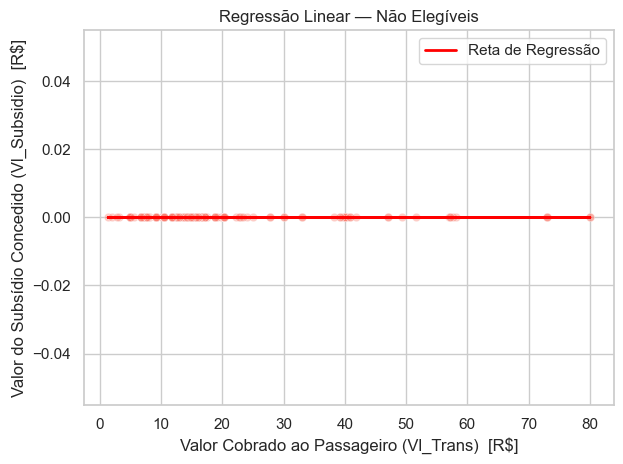


 GRUPO DE ELEGIBILIDADE : Elegíveis
   • β1 - Coeficiente Angular : -0.1928  → variação no subsídio por R$1 cobrado ao passageiro
   • β0 - Intercepto          : 3.9135  → subsídio base estimado quando Vl_Trans = 0
   • R² - Poder Explicativo   : 0.0867  → 8.7% da variação do subsídio explicada pelo valor cobrado
   • Volume da Amostra        : 400,823 transações
   • Total Pago em Subsídio   : R$ 1,015,272.30
-----------------------------------------------------------------


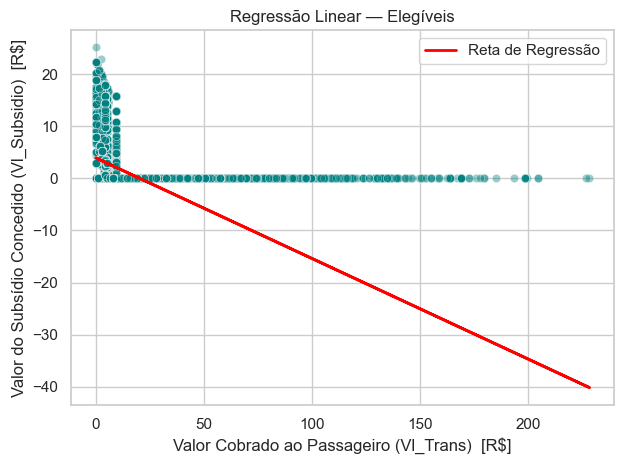

In [170]:
def executar_regressao(dframe, nome_grupo, sufixo_arquivo):
    """
    Executa regressão linear simples para um grupo de elegibilidade completo.

    Modelo: Vl_Subsidio = β0 + β1 * Vl_Trans
        X (independente) : Vl_Trans    — valor cobrado ao passageiro
        Y (dependente)   : Vl_Subsidio — valor do subsídio concedido
    """

    if len(dframe) < 5:
        print(f"[AVISO] Amostra insuficiente para regressão | Grupo: {nome_grupo}")
        return

    X = dframe[["Vl_Trans"]].fillna(0)
    y = dframe["Vl_Subsidio"].fillna(0)

    modelo = LinearRegression()
    modelo.fit(X, y)

    y_pred = modelo.predict(X)
    r2 = r2_score(y, y_pred)

    print(f"\n GRUPO DE ELEGIBILIDADE : {nome_grupo}")
    print(f"   • β1 - Coeficiente Angular : {modelo.coef_[0]:.4f}  → variação no subsídio por R$1 cobrado ao passageiro")
    print(f"   • β0 - Intercepto          : {modelo.intercept_:.4f}  → subsídio base estimado quando Vl_Trans = 0")
    print(f"   • R² - Poder Explicativo   : {r2:.4f}  → {r2*100:.1f}% da variação do subsídio explicada pelo valor cobrado")
    print(f"   • Volume da Amostra        : {len(dframe):,} transações")
    print(f"   • Total Pago em Subsídio   : R$ {y.sum():,.2f}")
    print("-" * 65)

    cor_grupo = "teal" if nome_grupo == "Elegíveis" else "salmon"

    sns.scatterplot(x=dframe["Vl_Trans"], y=dframe["Vl_Subsidio"], alpha=0.4, color=cor_grupo)
    plt.plot(dframe["Vl_Trans"], y_pred, color="red", linewidth=2, label="Reta de Regressão")
    plt.title(f"Regressão Linear — {nome_grupo}")
    plt.xlabel("Valor Cobrado ao Passageiro (Vl_Trans)  [R$]")
    plt.ylabel("Valor do Subsídio Concedido (Vl_Subsidio)  [R$]")
    plt.legend()
    plt.tight_layout()
    plt.show()
    # plt.savefig(f"regressao_{sufixo_arquivo}.png")
    plt.close()


# ------------------------------------------------------------------------------
# 2.1) REGRESSÃO POR GRUPO DE ELEGIBILIDADE
# ------------------------------------------------------------------------------
print("=" * 65)
print("  2.1) REGRESSÃO LINEAR POR GRUPO DE ELEGIBILIDADE")
print("=" * 65)

executar_regressao(Bu_nao_elegiveis, "Não Elegíveis", "grupo_nao_elegiveis")
executar_regressao(Bu_elegiveis,     "Elegíveis",     "grupo_elegiveis")

1) REGRESSÃO LINEAR POR APLICAÇÃO
 GRUPO: Não Elegíveis | NÍVEL: Aplicação | ALVO: 80-QR CODE UNITÁRIO
   • Coeficiente Angular (Beta 1): 0.0000
   • Intercepto (Beta 0):          0.0000
   • R² (Poder de Explicação):     1.0000
   • Volume da Amostra:            7,108 transações
------------------------------------------------------------


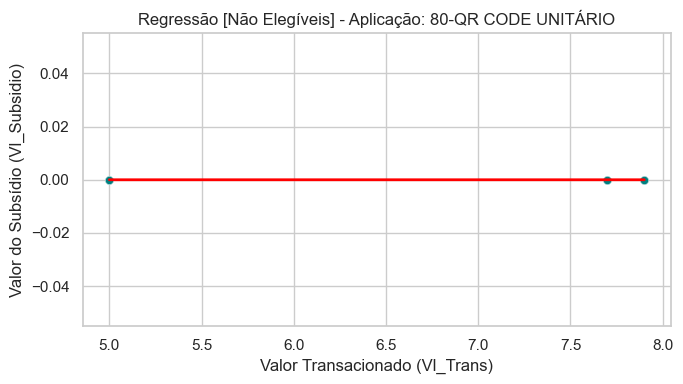

 GRUPO: Não Elegíveis | NÍVEL: Aplicação | ALVO: 450-CARTÃO EMPRESARIAL
   • Coeficiente Angular (Beta 1): 0.0000
   • Intercepto (Beta 0):          0.0000
   • R² (Poder de Explicação):     1.0000
   • Volume da Amostra:            1,123 transações
------------------------------------------------------------


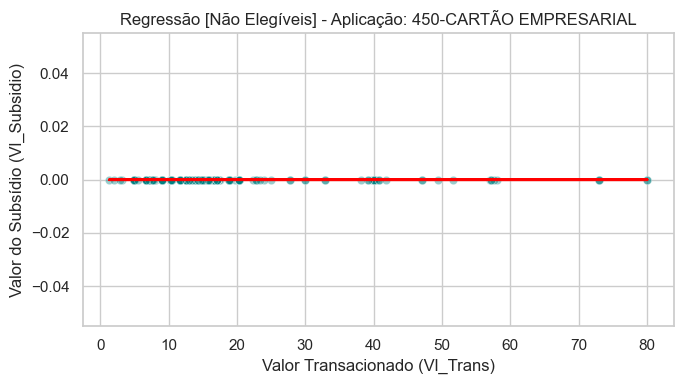

 GRUPO: Elegíveis | NÍVEL: Aplicação | ALVO: 100-EXPRESSO
   • Coeficiente Angular (Beta 1): -0.3248
   • Intercepto (Beta 0):          4.8207
   • R² (Poder de Explicação):     0.0989
   • Volume da Amostra:            16,277 transações
------------------------------------------------------------


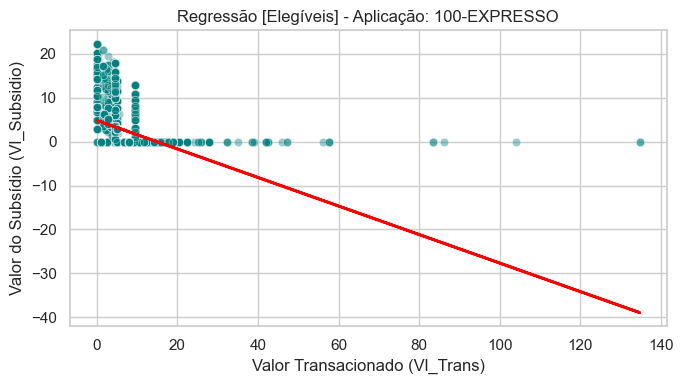

 GRUPO: Elegíveis | NÍVEL: Aplicação | ALVO: 400-VALE TRANSPORTE CONVENCIONAL
   • Coeficiente Angular (Beta 1): -0.1903
   • Intercepto (Beta 0):          3.8917
   • R² (Poder de Explicação):     0.0867
   • Volume da Amostra:            384,546 transações
------------------------------------------------------------


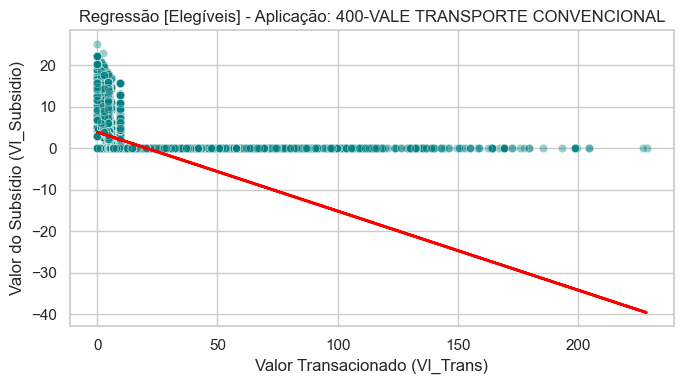

In [171]:
# ==============================================================================
# ## 2) REGRESSÃO LINEAR SEPARADA POR TODAS AS APLICAÇÕES
# ==============================================================================

def executar_regressao(dframe, coluna_filtro, valor_filtro, nome_grupo, nome_nivel, sufixo_arquivo):
    # Filtrando estritamente dentro do DataFrame do grupo correspondente
    df_sub = dframe[dframe[coluna_filtro] == valor_filtro].copy()
    
    if len(df_sub) < 5:
        print(f"Dados insuficientes para regressão: {nome_nivel} '{valor_filtro}' no grupo {nome_grupo}")
        return
    
    X = df_sub[["Vl_Trans"]].fillna(0)
    y = df_sub["Vl_Subsidio"].fillna(0)

    # Treinamento do Modelo
    modelo = LinearRegression()
    modelo.fit(X, y)
    
    y_pred = modelo.predict(X)
    r2 = r2_score(y, y_pred)
    
    print(f" GRUPO: {nome_grupo} | NÍVEL: {nome_nivel} | ALVO: {valor_filtro}")
    print(f"   • Coeficiente Angular (Beta 1): {modelo.coef_[0]:.4f}")
    print(f"   • Intercepto (Beta 0):          {modelo.intercept_:.4f}")
    print(f"   • R² (Poder de Explicação):     {r2:.4f}")
    print(f"   • Volume da Amostra:            {len(df_sub):,} transações")
    print("-" * 60)

    # Geração dos Gráficos Comparativos
    plt.figure(figsize=(7, 4))
    sns.scatterplot(x=df_sub["Vl_Trans"], y=df_sub["Vl_Subsidio"], alpha=0.4, color="teal")
    plt.plot(df_sub["Vl_Trans"], y_pred, color="red", linewidth=2)
    plt.title(f"Regressão [{nome_grupo}] - {nome_nivel}: {valor_filtro}")
    plt.xlabel("Valor Transacionado (Vl_Trans)")
    plt.ylabel("Valor do Subsídio (Vl_Subsidio)")
    plt.tight_layout()
    plt.savefig(f"regressao_{sufixo_arquivo}.png")
    plt.show()
    plt.close()

# ------------------------------------------------------------------------------
# 2.1) REGRESSÃO POR APLICAÇÃO 
# ------------------------------------------------------------------------------
print("="*60 + "\n1) REGRESSÃO LINEAR POR APLICAÇÃO\n" + "="*60)

# Rodando para as DUAS aplicações do Grupo Não Elegíveis
for i, app in enumerate(G_Nao_elegiveis):
    sufixo = f"app_nao_{i}"
    executar_regressao(Bu_nao_elegiveis, "Descricao_da_Aplicacao", app, "Não Elegíveis", "Aplicação", sufixo)

# Rodando para as DUAS aplicações do Grupo Elegíveis
for i, app in enumerate(G_Elegiveis):
    sufixo = f"app_ele_{i}"
    executar_regressao(Bu_elegiveis, "Descricao_da_Aplicacao", app, "Elegíveis", "Aplicação", sufixo)

In [172]:
# ==============================================================================
# FREQUÊNCIA DAS APLICAÇÕES
# ==============================================================================
print(f"\n{'='*70}")
print(f" FREQUÊNCIA DAS APLICAÇÕES")
print(f"{'='*70}")
freq = (
    Bu["Descricao_da_Aplicacao"]
    .value_counts()
    .reset_index()
)

freq.columns = [
    "Aplicacao",
    "Frequencia"
]

freq["Percentual (%)"] = (
    freq["Frequencia"]
    / freq["Frequencia"].sum()
) * 100


display(freq)


 FREQUÊNCIA DAS APLICAÇÕES


,Aplicacao,Frequencia,Percentual (%)
0,400-VALE TRANSPORTE CONVENCIONAL,384546,94.008615
1,100-EXPRESSO,16277,3.979181
2,80-QR CODE UNITÁRIO,7108,1.737668
3,450-CARTÃO EMPRESARIAL,1123,0.274536



 DISTRIBUIÇÃO DE FREQUÊNCIA — GRUPO: NÃO ELEGÍVEIS

🔹 Aplicação: 80-QR CODE UNITÁRIO | Total de Registros: 7,108
--------------------------------------------------


,Freq. Absoluta (Contagem),Freq. Relativa (%)
Vl_Trans,,
5.0,3075,43.26
7.7,39,0.55
7.9,3994,56.19


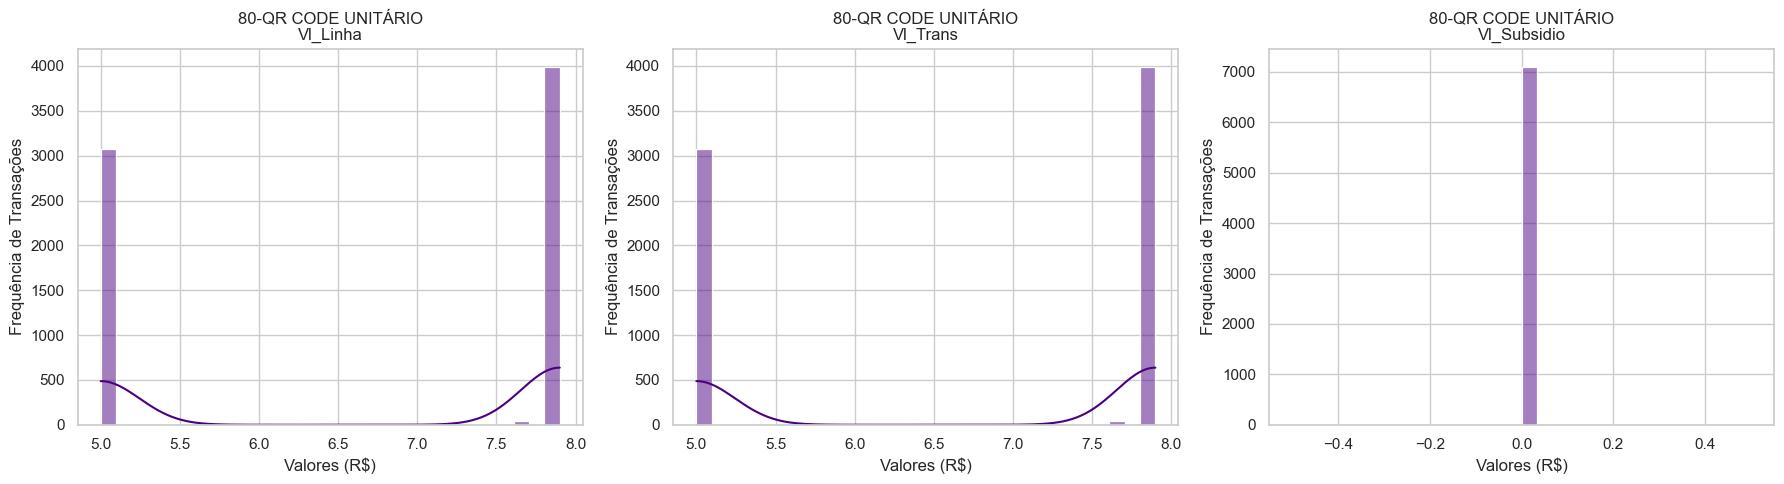


🔹 Aplicação: 450-CARTÃO EMPRESARIAL | Total de Registros: 1,123
--------------------------------------------------


,Freq. Absoluta (Contagem),Freq. Relativa (%)
Vl_Trans,,
1.36,1,0.09
1.98,1,0.09
2.87,1,0.09
3.16,1,0.09
5.00,16,1.42
5.50,1,0.09
6.65,1,0.09
6.70,310,27.60
7.00,2,0.18


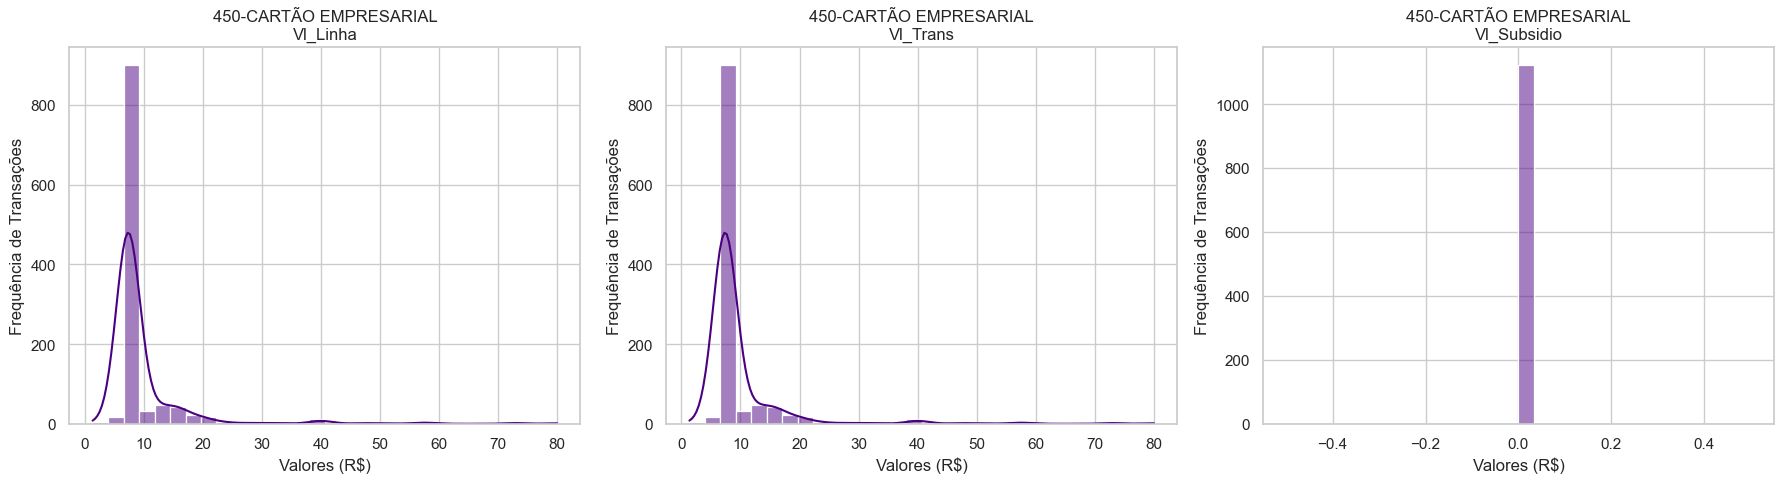


 DISTRIBUIÇÃO DE FREQUÊNCIA — GRUPO: ELEGÍVEIS

🔹 Aplicação: 400-VALE TRANSPORTE CONVENCIONAL | Total de Registros: 384,546
--------------------------------------------------


,Freq. Absoluta (Contagem),Freq. Relativa (%)
Vl_Trans,,
0.00,18300,4.76
0.04,1,0.00
0.15,18,0.00
0.25,1,0.00
0.27,1,0.00
0.30,607,0.16
0.43,1,0.00
0.50,32,0.01
0.55,1,0.00


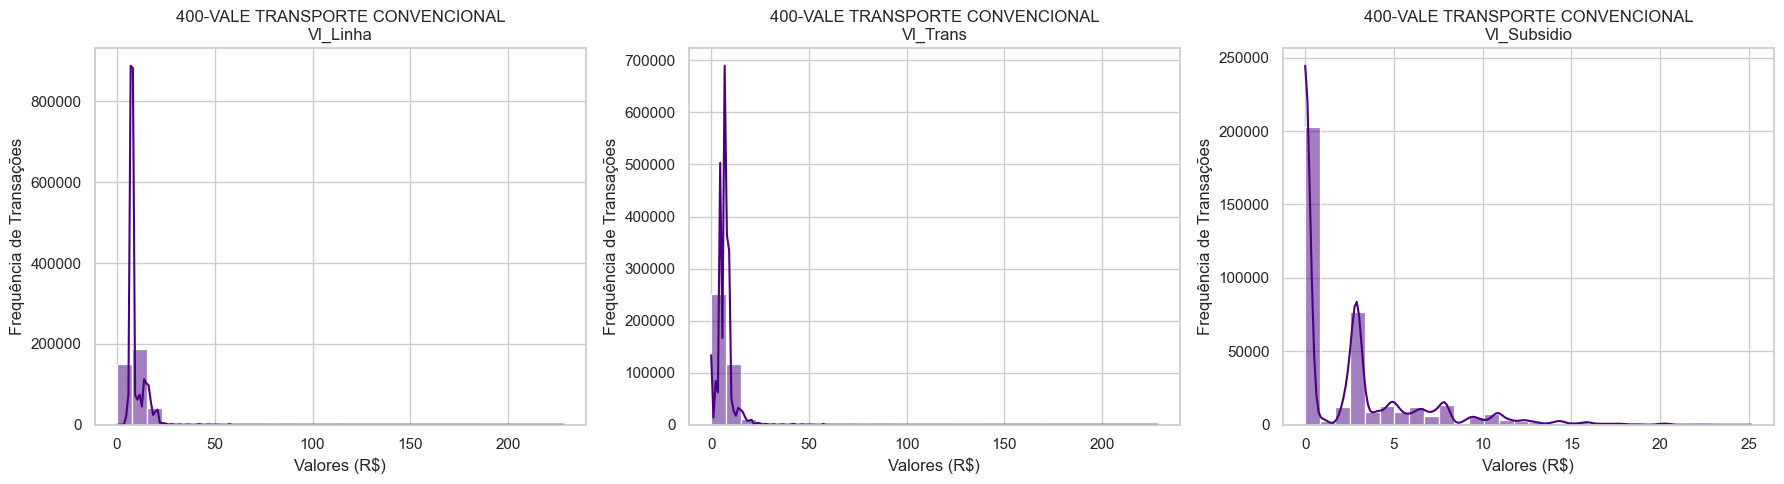


🔹 Aplicação: 100-EXPRESSO | Total de Registros: 16,277
--------------------------------------------------


,Freq. Absoluta (Contagem),Freq. Relativa (%)
Vl_Trans,,
0.0,846,5.20
0.3,21,0.13
1.0,84,0.52
1.5,24,0.15
1.6,16,0.10
1.7,47,0.29
1.8,4,0.02
2.3,84,0.52
2.5,10,0.06


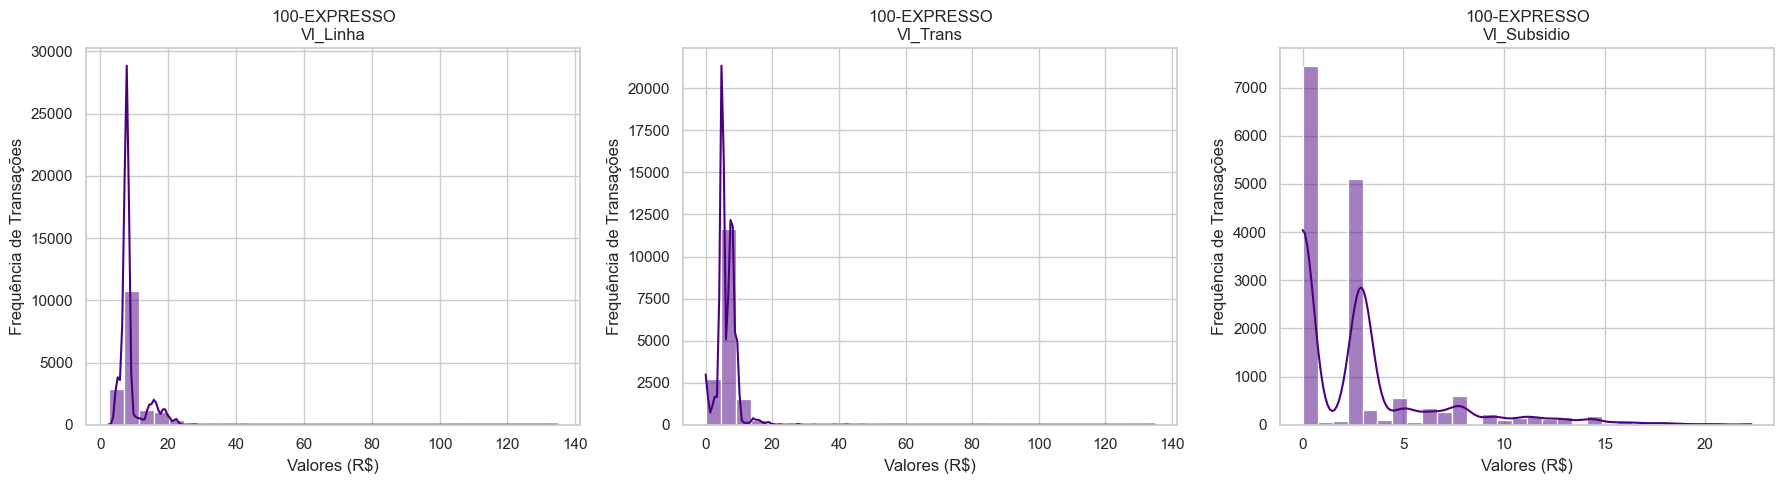

In [173]:
# ==============================================================================
# ##  DISTRIBUIÇÃO DE FREQUÊNCIA POR APLICAÇÃO 
# ==============================================================================

def calcular_distribuicao_aplicacao_original(dframe, nome_grupo):
    print(f"\n{'='*70}")
    print(f" DISTRIBUIÇÃO DE FREQUÊNCIA — GRUPO: {nome_grupo.upper()}")
    print(f"{'='*70}")
    
    # As três variáveis financeiras analisadas para cada aplicação
    colunas_financeiras = ["Vl_Linha", "Vl_Trans", "Vl_Subsidio"]
    aplicacoes = dframe['Descricao_da_Aplicacao'].unique()
    
    for idx, app in enumerate(aplicacoes):
        df_sub = dframe[dframe['Descricao_da_Aplicacao'] == app].copy()
        
        if len(df_sub) == 0:
            continue
            
        print(f"\n🔹 Aplicação: {app} | Total de Registros: {len(df_sub):,}")
        print("-" * 50)
        
        # Exibição da tabela de frequência (focada em Vl_Trans para referência)
        freq_abs = df_sub["Vl_Trans"].value_counts()
        freq_rel = df_sub["Vl_Trans"].value_counts(normalize=True) * 100
        tabela_freq = Pd.DataFrame({
            'Freq. Absoluta (Contagem)': freq_abs,
            'Freq. Relativa (%)': freq_rel.round(2)
        }).sort_index()

        
        
        display(tabela_freq.head(10))


        
        # Grid de subplots exatamente (1 linha, 3 colunas)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        for i, col in enumerate(colunas_financeiras):
            sns.histplot(
                data=df_sub,
                x=col,
                bins=30,         # Mantendo os seus 30 bins originais
                kde=True,        # Mantendo o seu KDE ativado
                ax=axes[i],
                color="indigo"
            )
            axes[i].set_title(f"{app}\n{col}")
            axes[i].set_xlabel("Valores (R$)")
            axes[i].set_ylabel("Frequência de Transações")
            
        plt.tight_layout()
        sufixo = nome_grupo.lower().replace(" ", "_")
        plt.savefig(f"histograma_original_app_{sufixo}_{idx}.png")
        plt.show()
        plt.close()


# Executa para o grupo Não Elegíveis
calcular_distribuicao_aplicacao_original(Bu_nao_elegiveis, "Não Elegíveis")

# Executa para o grupo Elegíveis
calcular_distribuicao_aplicacao_original(Bu_elegiveis, "Elegíveis")

Grafico de Histograma para os dados do grupo:  NÃO ELEGIVEIS Para Bilhete Unico


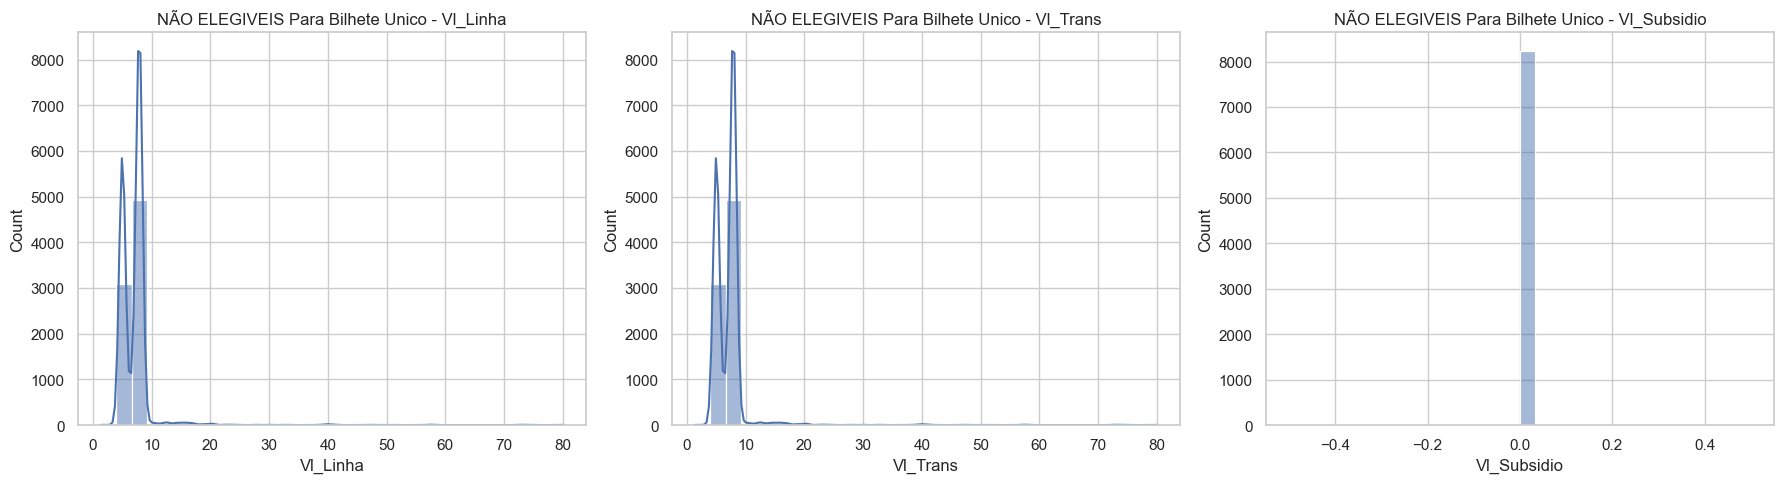

Grafico de Histograma para os dados do grupo:  ELEGIVEIS Para Bilhete Unico


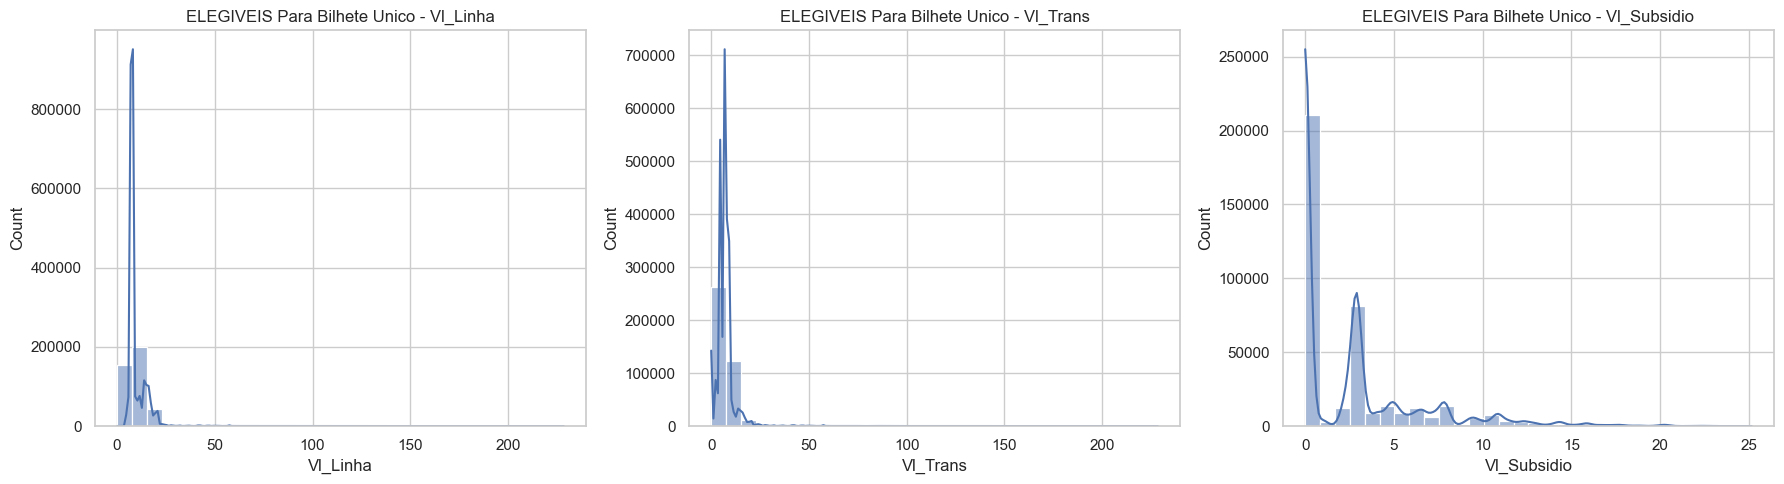

In [174]:
# ==============================================================================
# Historigrama  com as apliações 
def histogramas(dframe, nome):

 fig, axes = plt.subplots(1, 3, figsize=(18,5))

 colunas = [
  "Vl_Linha",
  "Vl_Trans",
  "Vl_Subsidio"
 ]
 print("Grafico de Histograma para os dados do grupo: ", nome)

 for i, col in enumerate(colunas):

  sns.histplot(
   dframe[col],
   bins=30,
   kde=True,
   ax=axes[i]
  )

  axes[i].set_title(f"{nome} - {col}")

 plt.tight_layout()
 plt.show()
 plt.close()
 
histogramas(Bu_nao_elegiveis,"NÃO ELEGIVEIS Para Bilhete Unico")
histogramas(Bu_elegiveis,"ELEGIVEIS Para Bilhete Unico")


🚨 ANÁLISE DE OUTLIERS (IQR) — GRUPO: NÃO ELEGÍVEIS

🔹 Aplicação: 80-QR CODE UNITÁRIO
   • Limite Inferior: R$ 0.65 | Limite Superior: R$ 12.25
   • Outliers Reais: 0 de 7,108 (0.00%)
--------------------------------------------------


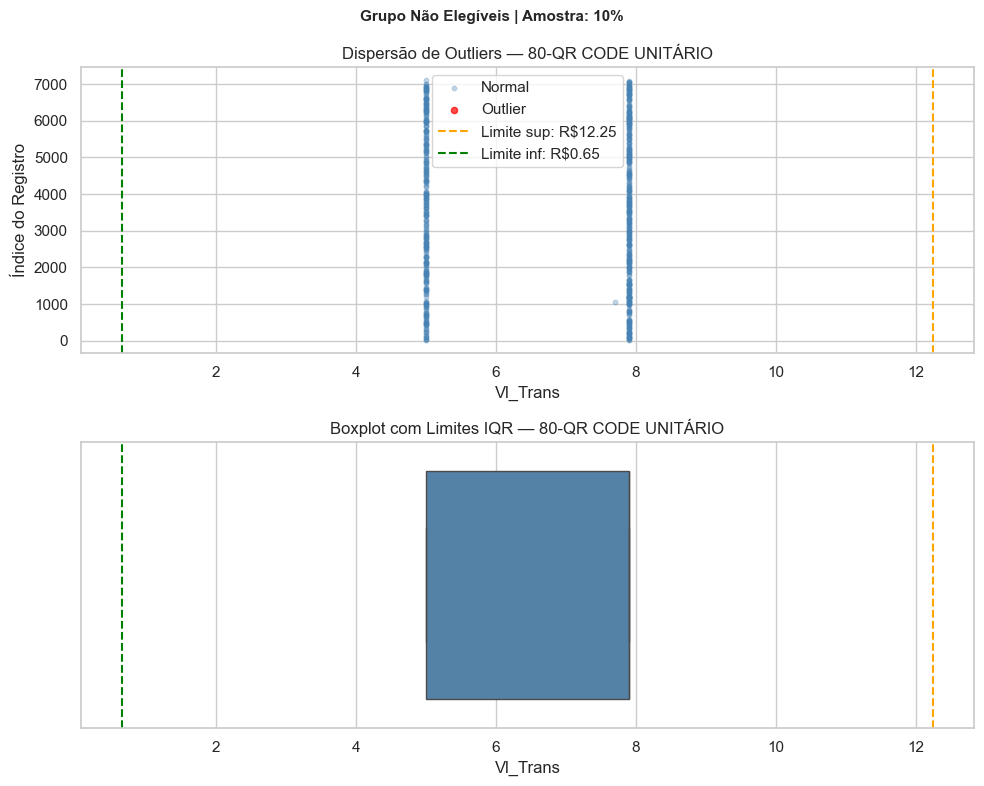


🔹 Aplicação: 450-CARTÃO EMPRESARIAL
   • Limite Inferior: R$ 4.90 | Limite Superior: R$ 9.70
   • Outliers Reais: 205 de 1,123 (18.25%)
--------------------------------------------------


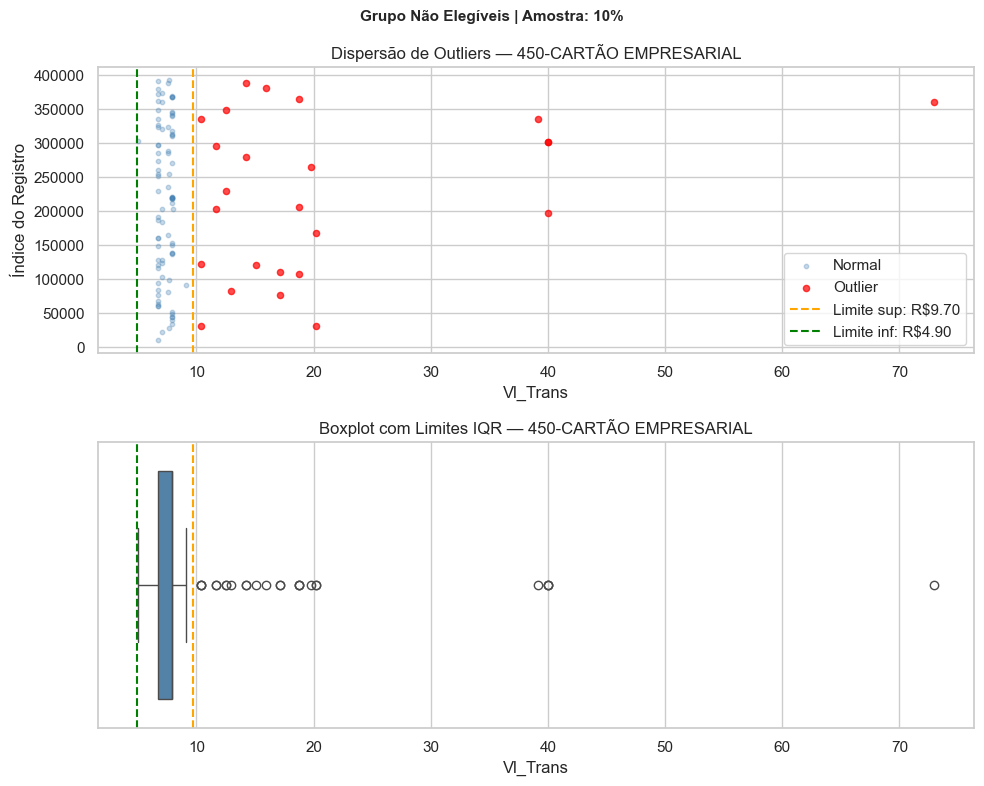


🚨 ANÁLISE DE OUTLIERS (IQR) — GRUPO: ELEGÍVEIS

🔹 Aplicação: 400-VALE TRANSPORTE CONVENCIONAL
   • Limite Inferior: R$ -4.72 | Limite Superior: R$ 7.88
   • Outliers Reais: 38,113 de 384,546 (9.91%)
--------------------------------------------------


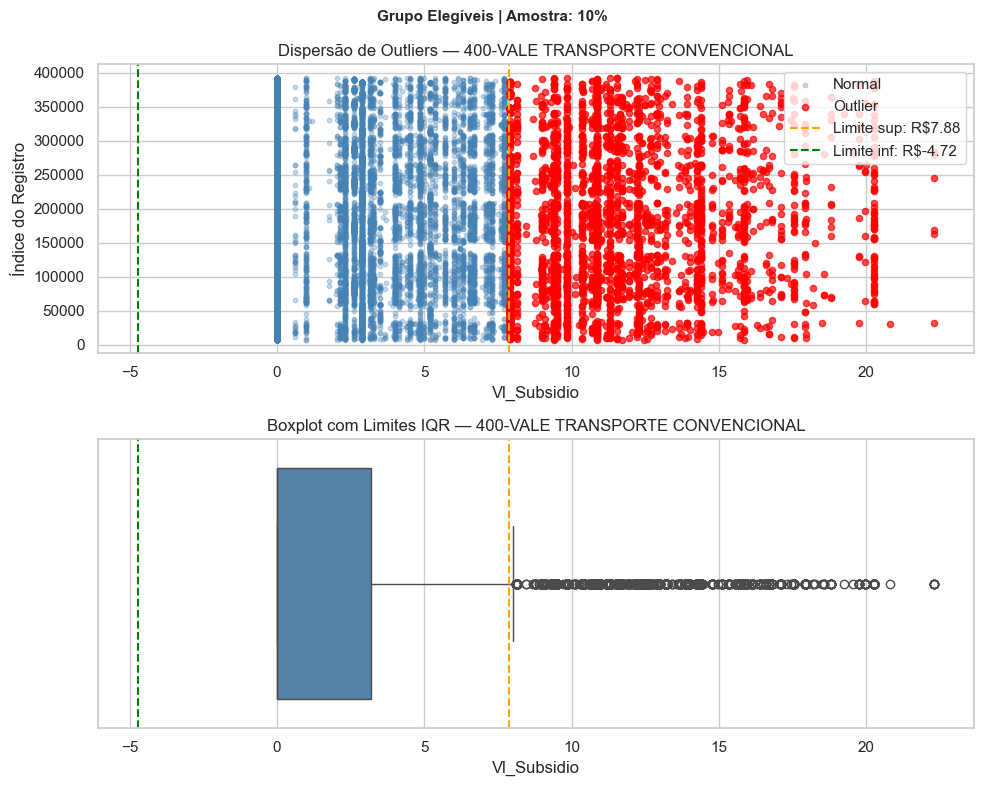


🔹 Aplicação: 100-EXPRESSO
   • Limite Inferior: R$ -4.35 | Limite Superior: R$ 7.25
   • Outliers Reais: 1,990 de 16,277 (12.23%)
--------------------------------------------------


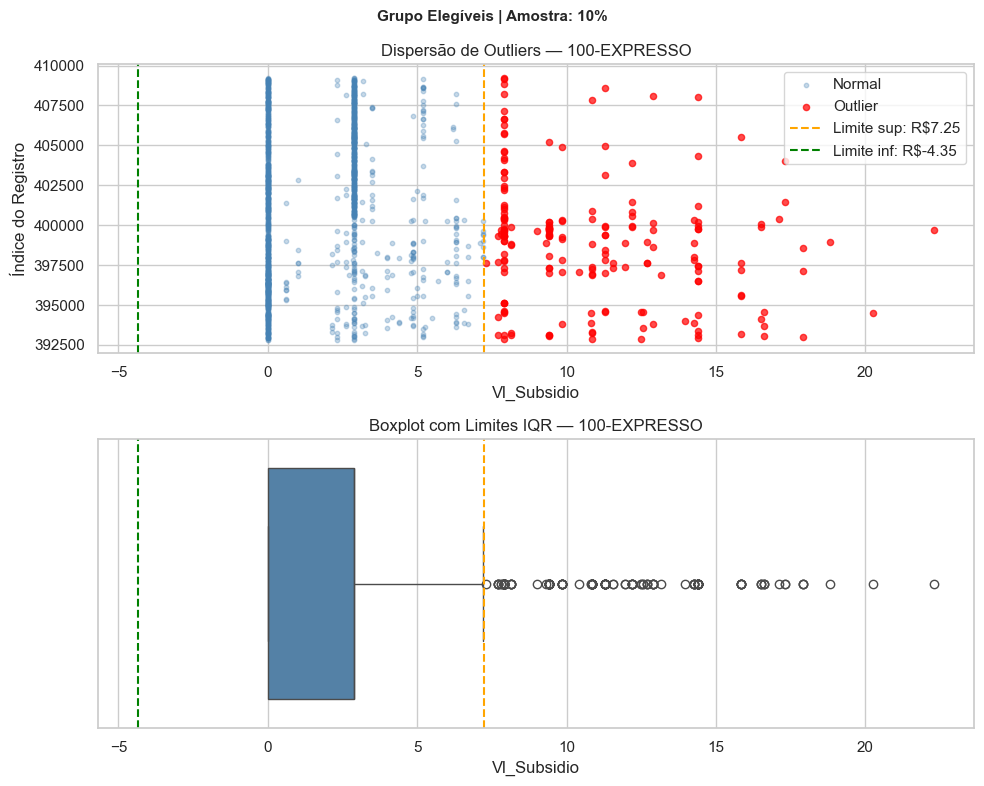

In [175]:
# ==============================================================================
# ## 4) IDENTIFICAÇÃO DE OUTLIERS POR APLICAÇÃO (MÉTODO IQR)
# ==============================================================================

def analisar_outliers_aplicacao(dframe, coluna_valores, nome_grupo, fracao=0.1):
    print(f"\n{'='*70}")
    print(f"🚨 ANÁLISE DE OUTLIERS (IQR) — GRUPO: {nome_grupo.upper()}")
    print(f"{'='*70}")
    
    aplicacoes = dframe['Descricao_da_Aplicacao'].unique()
    
    for idx, app in enumerate(aplicacoes):
        df_sub = dframe[dframe['Descricao_da_Aplicacao'] == app].copy()
        
        if len(df_sub) == 0:
            continue
            
        # Cálculo do IQR no DataFrame completo da Aplicação
        Q1 = df_sub[coluna_valores].quantile(0.25)
        Q3 = df_sub[coluna_valores].quantile(0.75)
        IQR = Q3 - Q1
        
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR
        
        # Amostragem para plotagem 
        amostra = df_sub.sample(frac=fracao, random_state=42) if len(df_sub) > 1000 else df_sub.copy()
        
        # Classificação dos registros na amostra
        outliers_amostra = amostra[(amostra[coluna_valores] < limite_inf) | (amostra[coluna_valores] > limite_sup)]
        normais_amostra  = amostra[(amostra[coluna_valores] >= limite_inf) & (amostra[coluna_valores] <= limite_sup)]
        
        total_outliers_real = len(df_sub[(df_sub[coluna_valores] < limite_inf) | (df_sub[coluna_valores] > limite_sup)])
        
        print(f"\n🔹 Aplicação: {app}")
        print(f"   • Limite Inferior: R$ {limite_inf:.2f} | Limite Superior: R$ {limite_sup:.2f}")
        print(f"   • Outliers Reais: {total_outliers_real:,} de {len(df_sub):,} ({total_outliers_real/len(df_sub)*100:.2f}%)")
        print("-" * 50)
        
        # Estrutura de Gráficos Espelhados (Scatter + Boxplot) para evidenciar os outliers
        fig, axes = plt.subplots(2, 1, figsize=(10, 8))
        
        # Gráfico 1: Scatter
        axes[0].scatter(normais_amostra[coluna_valores], normais_amostra.index, color="steelblue", alpha=0.3, s=10, label="Normal")
        axes[0].scatter(outliers_amostra[coluna_valores], outliers_amostra.index, color="red", alpha=0.7, s=20, label="Outlier")
        axes[0].axvline(limite_sup, color="orange", linestyle="--", label=f"Limite sup: R${limite_sup:.2f}")
        axes[0].axvline(limite_inf, color="green",  linestyle="--", label=f"Limite inf: R${limite_inf:.2f}")
        axes[0].set_title(f"Dispersão de Outliers — {app}")
        axes[0].set_xlabel(coluna_valores)
        axes[0].set_ylabel("Índice do Registro")
        axes[0].legend()
        
        # Gráfico 2: Boxplot
        sns.boxplot(x=amostra[coluna_valores], ax=axes[1], color="steelblue")
        axes[1].axvline(limite_sup, color="orange", linestyle="--")
        axes[1].axvline(limite_inf, color="green",  linestyle="--")
        axes[1].set_title(f"Boxplot com Limites IQR — {app}")
        axes[1].set_xlabel(coluna_valores)
        
        plt.suptitle(f"Grupo {nome_grupo} | Amostra: {fracao*100:.0f}%", fontsize=11, fontweight="bold")
        plt.tight_layout()
        
        sufixo = nome_grupo.lower().replace(" ", "_")
        # plt.savefig(f"outliers_app_{sufixo}_{idx}.png")
        plt.show()
        plt.close()

# --- Execução Direta ---
# Avaliando outliers do valor pago no grupo Não Elegíveis
analisar_outliers_aplicacao(Bu_nao_elegiveis, "Vl_Trans", "Não Elegíveis")

# Avaliando outliers do subsídio recebido no grupo Elegíveis
analisar_outliers_aplicacao(Bu_elegiveis, "Vl_Subsidio", "Elegíveis")

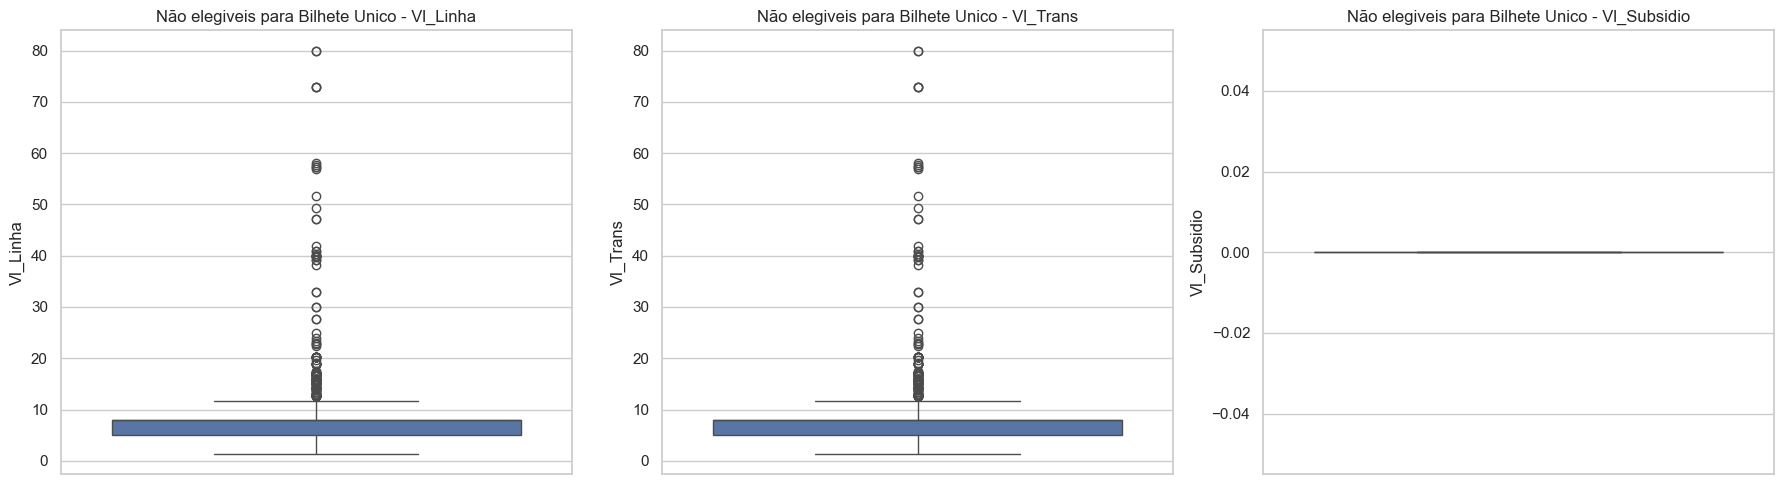

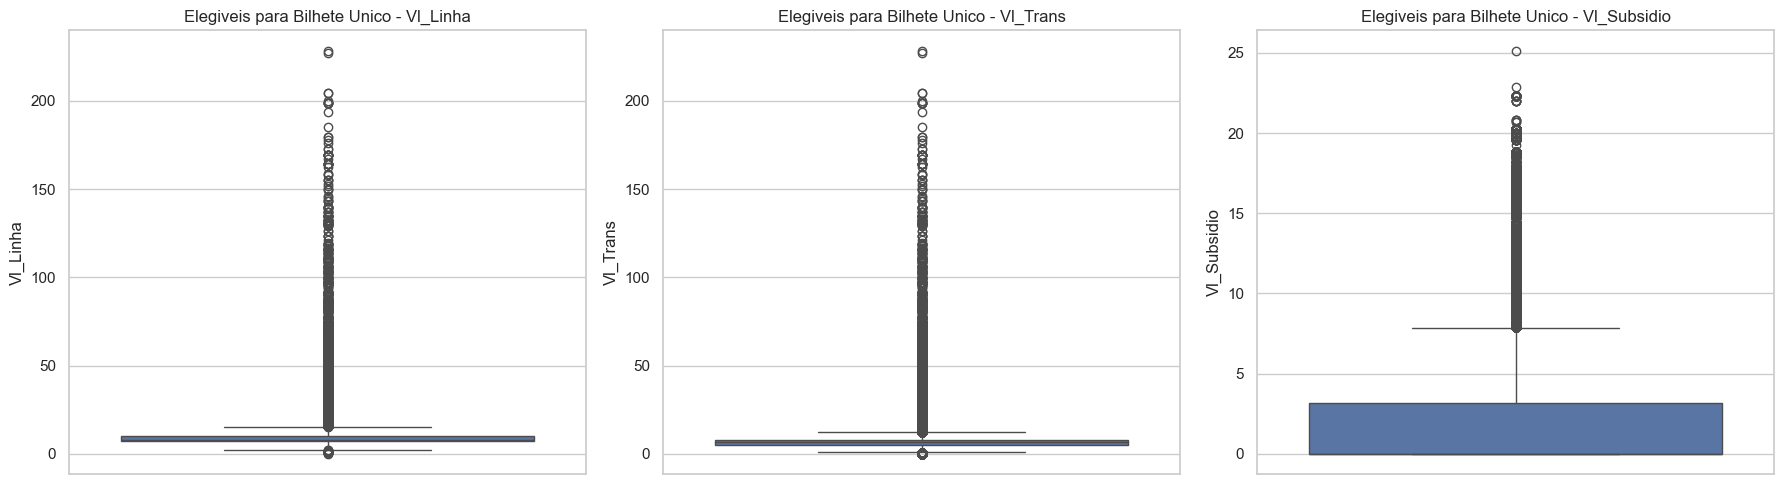

In [176]:
def boxplots(dframe, nome):

    fig, axes = plt.subplots(1,3, figsize=(18,5))

    colunas = [
        "Vl Linha",
        "Vl Trans",
        "Vl Subsídio"
    ]

    for i, col in enumerate(colunas):

        sns.boxplot(
            y=dframe[col],
            ax=axes[i]
        )

        axes[i].set_title(f"{nome} - {col}")

    plt.tight_layout()
    plt.show()
def boxplots(dframe, nome): 
 fig, axes = plt.subplots(1, 3, figsize=(18, 5))

 colunas = [
  "Vl_Linha",
  "Vl_Trans",
  "Vl_Subsidio"
 ]

 for i, col in enumerate(colunas):
  sns.boxplot(
   y=dframe[col],
   ax=axes[i]
  )
  axes[i].set_title(f"{nome} - {col}")

 plt.tight_layout()
 plt.show()

boxplots(Bu_nao_elegiveis, "Não elegiveis para Bilhete Unico")
boxplots(Bu_elegiveis, "Elegiveis para Bilhete Unico")
